DAY 1 — Data Preparation

In [ ]:
#Load Dataset
import pandas as pd

df = pd.read_csv("claim_data.csv")





In [ ]:
df.head()

,Claim ID,Provider ID,Patient ID,Date of Service,Billed Amount,Procedure Code,Diagnosis Code,Allowed Amount,Paid Amount,Insurance Type,Claim Status,Reason Code,Follow-up Required,AR Status,Outcome
0,0HO1FSN4AP,126528997,7936697103,08/07/2024,304,99231,A02.1,218,203,Self-Pay,Paid,Incorrect billing information,Yes,Pending,Partially Paid
1,9U86CI2P5A,6986719948,1547160031,06/21/2024,348,99213,A16.5,216,206,Medicare,Paid,Pre-existing condition,Yes,Open,Denied
2,1QEU1AIDAU,1355108115,2611585318,07/04/2024,235,99213,A00.1,148,119,Commercial,Under Review,Duplicate claim,No,Denied,Denied
3,WH7XDS8CEO,9991055906,7167948632,05/26/2024,112,99215,A18.6,79,69,Medicare,Denied,Authorization not obtained,No,Partially Paid,Denied
4,M6OJEZ8KGI,7382167012,2140226267,07/16/2024,406,99238,A17.9,320,259,Medicare,Denied,Authorization not obtained,No,On Hold,Denied


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Claim ID            1000 non-null   str  
 1   Provider ID         1000 non-null   int64
 2   Patient ID          1000 non-null   int64
 3   Date of Service     1000 non-null   str  
 4   Billed Amount       1000 non-null   int64
 5   Procedure Code      1000 non-null   int64
 6   Diagnosis Code      1000 non-null   str  
 7   Allowed Amount      1000 non-null   int64
 8   Paid Amount         1000 non-null   int64
 9   Insurance Type      1000 non-null   str  
 10  Claim Status        1000 non-null   str  
 11  Reason Code         1000 non-null   str  
 12  Follow-up Required  1000 non-null   str  
 13  AR Status           1000 non-null   str  
 14  Outcome             1000 non-null   str  
dtypes: int64(6), str(9)
memory usage: 117.3 KB


In [ ]:
#Drop Unnecessary Columns
df = df.drop(["Claim ID", "Patient ID", "Provider ID"], axis=1)


In [ ]:
#Handle Missing Values
print(df.isnull().sum())

# Simple handling
df = df.fillna("Unknown")


Date of Service       0
Billed Amount         0
Procedure Code        0
Diagnosis Code        0
Allowed Amount        0
Paid Amount           0
Insurance Type        0
Claim Status          0
Reason Code           0
Follow-up Required    0
AR Status             0
Outcome               0
dtype: int64


In [ ]:
#Feature Selection
X = df.drop("Outcome", axis=1)
y = df["Outcome"]


In [ ]:
#Encode Categorical Data
X = pd.get_dummies(X, drop_first=True).astype(int)


In [ ]:
#Convert Target to Numeric
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)


DAY 2 — Model Building

In [ ]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
#Train Model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
#Prediction
y_pred = model.predict(X_test)


In [ ]:
y_pred

array([0, 1, 1, 1, 2, 0, 1, 1, 1, 0, 2, 1, 1, 0, 2, 1, 1, 1, 2, 1, 0, 0,
       0, 1, 2, 0, 1, 1, 0, 0, 0, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1,
       2, 0, 1, 1, 0, 1, 2, 2, 1, 1, 2, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1,
       1, 1, 2, 1, 2, 1, 2, 0, 1, 1, 2, 1, 2, 1, 1, 1, 1, 2, 1, 0, 0, 1,
       1, 0, 2, 0, 1, 1, 1, 0, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 0, 2, 2, 1, 1, 1, 1, 0, 1, 1, 1, 2, 1, 1, 1, 1,
       1, 0, 1, 2, 1, 0, 0, 2, 1, 0, 1, 1, 1, 0, 2, 1, 0, 1, 1, 1, 0, 2,
       0, 1, 1, 0, 2, 0, 2, 2, 1, 0, 0, 2, 2, 2, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 2, 2, 2, 2, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 2, 2, 1, 1, 0,
       2, 1])

In [ ]:
#Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.295

Confusion Matrix:
 [[12 37 15]
 [16 36 15]
 [21 37 11]]

Classification Report:
               precision    recall  f1-score   support

           0       0.24      0.19      0.21        64
           1       0.33      0.54      0.41        67
           2       0.27      0.16      0.20        69

    accuracy                           0.29       200
   macro avg       0.28      0.29      0.27       200
weighted avg       0.28      0.29      0.27       200



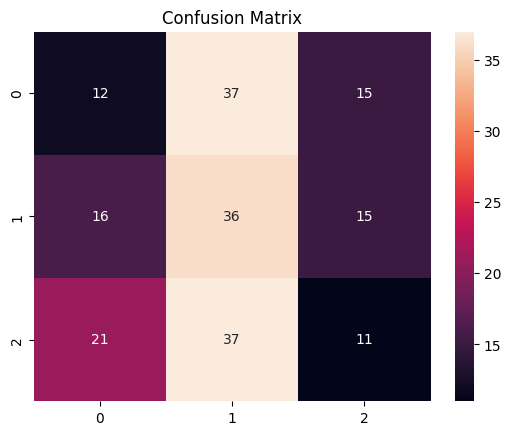

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()


DAY 3 — Save Model + API

In [ ]:
#save model
import pickle

pickle.dump(model, open("fraud_model.pkl", "wb"))


In [ ]:
fraud_model = pickle.load(open("fraud_model.pkl", "rb"))

@app.route("/predict_fraud", methods=["POST"])
def predict_fraud():
    data = request.json

    df = pd.DataFrame([data])
    df = pd.get_dummies(df)
    df = df.reindex(columns=fraud_model.feature_names_in_, fill_value=0)

    prediction = fraud_model.predict(df)[0]

    result = "Fraud 🚨" if prediction == 1 else "Not Fraud ✅"

    return jsonify({"Fraud Prediction": result})


In [ ]:
print(fraud_model.feature_names_in_)
